In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.ndimage import rotate as rot
from IPython.display import HTML, Image
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit, minimize
from numpy.random import normal
import random
from matplotlib.colors import LogNorm, Normalize

from hcipy import *
from matplotlib import colors


In [2]:
coron_psfs = np.load("data/coron_test/coron_psfs.npy")
coron_seps = np.load("data/coron_test/coron_rs.npy")
coron_psfs_star = np.load("data/coron_test/coron_psf_star_ab.npy")
coron_psfs.shape, coron_seps.shape

((48, 660, 660), (48,))

In [10]:
pln_psfs_adi = np.load("data/pln_test/pln_psfs_adi.npy")
pln_psfs_star_errs = np.load("data/pln_psf_star_ab_cube.npy")
pln_seps_adi = np.load("data/pln_test/pln_rs_adi.npy")
pln_thetas_adi = np.load("data/pln_test/pln_thetas_adi.npy")
pln_psfs_adi.shape, pln_psfs_star_errs.shape,  pln_seps_adi.shape, pln_thetas_adi.shape

((5, 20, 6), (20, 6), (5,), (20,))

In [20]:
pln_psfs = np.load("data/pln/pln_psfs.npy")
pln_seps = np.load("data/pln/pln_rs.npy")
pln_thetas = np.load("data/pln/pln_thetas.npy")
pln_psfs.shape, pln_seps.shape, pln_thetas.shape

((13, 24, 6), (13,), (24,))

In [34]:
coron_psfs_c6 = np.load("data/coron/coron_psfs_c6.npy")
coron_psfs_c4 = np.load("data/coron/coron_psfs_c4.npy")
coron_psfs_c2 = np.load("data/coron/coron_psfs_c2.npy")
coron_psfs_star_c2 = np.load("data/coron/coron_psf_star_ab_cube_c2.npy")
coron_psfs_star_c4 = np.load("data/coron/coron_psf_star_ab_cube_c4.npy")
coron_psfs_star_c6 = np.load("data/coron/coron_psf_star_ab_cube_c6.npy")

In [31]:
def pln_dot_product(pln_data, separations, thetas, sep, theta1, theta2, degree = True):
    thetas_data = pln_data[np.where(separations==sep)[0][0]]
    interp = CubicSpline(thetas, thetas_data)
    if degree:
        angle_rad_1 = np.deg2rad(theta1)
        angle_rad_2 = np.deg2rad(theta2)
        # theta_diff = np.abs(angle_rad_1 - angle_rad_2)
        psf1 = interp(angle_rad_1)
        psf2 = interp(angle_rad_2)
        
    else:
        # theta_diff = np.abs(theta1 - theta2)
        psf1 = interp(theta1)
        psf2 = interp(theta2)
    psf1_normed = psf1/np.linalg.norm(psf1)
    psf2_normed = psf2/np.linalg.norm(psf2)
    return psf1_normed.T @ psf2_normed


def coron_dot_product(coron_data, separations, sep, theta1, theta2, degree = True):
    psf =coron_data[np.where(separations==sep)[0][0]]
    if degree == False:
        angle_deg_1 = np.rad2deg(theta1)
        angle_deg_2 = np.rad2deg(theta2)
        psf_1 = rot(psf, angle_deg_1, reshape = False) #Is there a way to get around this 
        psf_2 = rot(psf, angle_deg_2, reshape = False)
        psf_1d_1 = psf_1.ravel()
        psf_1d_2 = psf_2.ravel()
        # theta_diff = np.abs(theta1- theta2)
    else:
        angle_rad_1 = np.deg2rad(theta1)
        angle_rad_2 = np.deg2rad(theta2)
        psf_1 = rot(psf, theta1, reshape = False)
        psf_2 = rot(psf, theta2, reshape = False)
        psf_1d_1 = psf_1.ravel()
        psf_1d_2 = psf_2.ravel()
        # theta_diff = np.abs(angle_rad_1- angle_rad_2)
    psf1_normed = psf_1d_1/np.linalg.norm(psf_1d_1)
    psf2_normed = psf_1d_2/np.linalg.norm(psf_1d_2)
    return psf1_normed.T @ psf2_normed 

def fm_data_gen(coron_data, coron_star, rot_angles, sep_inds,  FR):
    fm_data_combined = np.zeros((len(sep_inds), len(rot_angles), coron_data.shape[1], coron_data.shape[2]))
    fm_data_planet = np.zeros((20, 20, 660, 660))
    planet_windows_fm = np.zeros(fm_data_combined.shape)
    pre_fm_rms = np.zeros((len(sep_inds),len(rot_angles)))
    for i, ind in enumerate(sep_inds):
        for j, angle in enumerate(rot_angles):
            new_psf = rot(coron_data[ind], angle, reshape = False)
            planet_center_y, planet_center_x = np.unravel_index(np.argmax(new_psf), new_psf.shape)
            y, x = np.ogrid[:660, :660]
            distance_from_center = np.sqrt((x - planet_center_x)**2 + (y - planet_center_y)**2)
            mask = distance_from_center<42
            planet_windows_fm[i,j] = mask
            fm_data_planet[i, j] = FR*new_psf
            fm_data_combined[i, j] = coron_star[j] + FR*new_psf
            pre_fm_rms[i,j] = np.sqrt(np.mean(fm_data_planet[i, j][mask]**2))
    return(fm_data_combined, fm_data_planet, planet_windows_fm, pre_fm_rms)

def forward_model(combined_psf, planet_psf):
    model_result = np.zeros_like(planet_psf)
    for i in range (0,planet_psf.shape[0]):
        for j in range(0, planet_psf.shape[1]):
            median_arr = np.delete(combined_psf[i],j , axis = 0)
            median = np.median(median_arr, axis = 0)
            model_result[i,j] = planet_psf[i,j]-median
    return model_result

def post_fm_I_rms(fm_result, planet_windows):
    post_fm_rms = np.zeros((fm_result.shape[0],fm_result.shape[1]))
    for i in range(0, fm_result.shape[0]):
        for j in range(0, fm_result.shape[1]):
            mask = planet_windows[i,j].astype(bool)
            post_fm_rms[i,j] = np.sqrt(np.mean(fm_result[i, j][mask]**2))
    return(post_fm_rms)

def pre_post_ratio(post_fm_rms, pre_fm_rms):
    rms_ratio = np.mean(post_fm_rms/pre_fm_rms, axis = 1)
    return (rms_ratio)

In [11]:
coron_seps_adi_far = np.arange(8.5,11, 0.5)
rot_excl_angles = np.rad2deg(np.linspace(np.pi/18, (7*np.pi)/36, 20, endpoint=True)) #New exclusion angles defined
sep_inds_far = [np.where(coron_seps == x)[0][0] for x in coron_seps_adi_far]


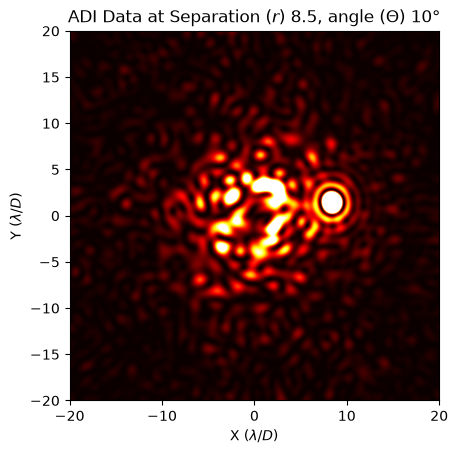

In [12]:
adi_data_cl_wstar = np.zeros((5, 20, 660, 660))
adi_data_far_wstar = np.zeros((5, 20, 660, 660))
FR = 1e-5
for i, ind in enumerate(sep_inds_far):
    for j, angle in enumerate(rot_excl_angles):
        new_psf = rot(coron_psfs[ind], angle, reshape = False)
        adi_data_far_wstar[i, j] = coron_psfs_star + FR*new_psf


dpix = 0.06060606060606233
fig, ax = plt.subplots()
image = ax.imshow(adi_data_far_wstar[0, 0], cmap='hot', extent = [-330*dpix,330*dpix, -330*dpix, 330*dpix], 
                  vmin = np.min(adi_data_far_wstar), vmax = np.percentile(adi_data_far_wstar, 99))
ax.set_xlim(-330*dpix,330*dpix)
ax.set_ylim(-330*dpix,330*dpix)
ax.set_title(rf"ADI Data at Separation ($r$) {coron_seps_adi_far[0]}, angle ($\Theta$)"+ f" {int(rot_excl_angles[0])}\u00b0") 
ax.set_xlabel(r"X ($\lambda/D$)")
ax.set_ylabel(r"Y ($\lambda/D$)")
plt.show()

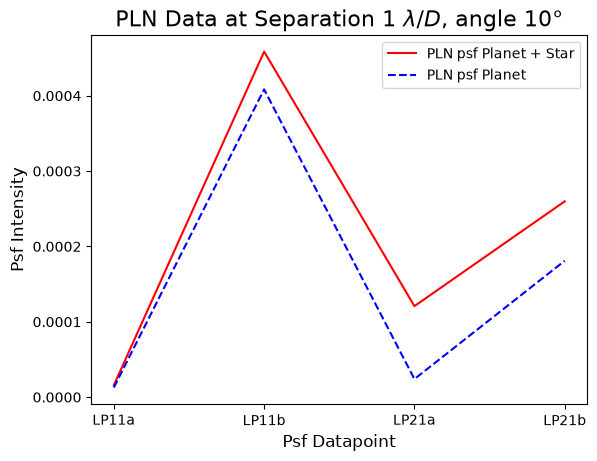

In [19]:
adi_data_pln_wstar_diffs = np.zeros((5, 20, 6))
FR_pln = 1e-3
for i in range (len(pln_seps_adi)):
        for j in range(len(pln_thetas_adi)):
                adi_data_pln_wstar_diffs[i, j] = pln_psfs_star_errs[j] + FR_pln*pln_psfs_adi[i,j]

fig, ax = plt.subplots()
ax.plot(np.arange(2,6), adi_data_pln_wstar_diffs[1, 0, 1:5], label = "PLN psf Planet + Star", c = "r")
ax.plot(np.arange(2,6), 1e-3*pln_psfs_adi[1, 0, 1:5], label = "PLN psf Planet", c= "b", ls = "--")
ax.set_xticks([2, 3, 4, 5])  
ax.set_xticklabels(["LP11a", "LP11b", "LP21a", "LP21b"])  
ax.set_xlabel("Psf Datapoint", fontsize = 12)
ax.set_ylabel("Psf Intensity", fontsize = 12)
ax.set_title(f"PLN Data at Separation 1 $\lambda/D$, angle 10\u00b0", fontsize = 16)
ax.legend()
plt.show()

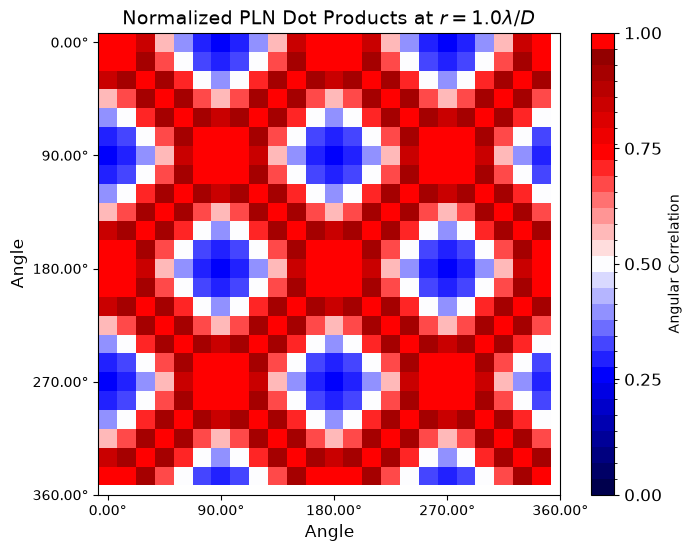

In [26]:
pln_dot_matrix_1 = np.zeros((len(pln_thetas), len(pln_thetas)))
for j, th1 in enumerate(pln_thetas):
        for k, th2 in enumerate(pln_thetas):
            pln_dot_matrix_1[j,k] = pln_dot_product(pln_psfs, pln_seps, pln_thetas, 1, th1, th2, degree = False)

cmap = plt.cm.seismic
cmaplist = [cmap(i) for i in range(cmap.N)]
cmaplist[-1]='red' 
cmap = colors.LinearSegmentedColormap.from_list('Custom cmap', cmaplist, cmap.N)
norm = colors.BoundaryNorm(list(np.linspace(0, 1, 30)), cmap.N)
fig, ax = plt.subplots(figsize = (8,6))
plt.grid(False)
img = ax.imshow(pln_dot_matrix_1, cmap=cmap, norm=norm, animated=True)
cbar = plt.colorbar(img, label = "Angular Correlation", cmap = "seismic")
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])  
cbar.ax.tick_params(labelsize=12)
x_values = np.linspace(0, 2 * np.pi, 25)*180/np.pi
y_values = np.linspace(0, 2 * np.pi, 25)*180/np.pi
ax.set_xticks(np.arange(len(x_values))[::6])
ax.set_yticks(np.arange(len(y_values))[::6])
ax.set_xticklabels([f'{val:.2f}\u00b0' for val in x_values][::6], fontsize = 10)
ax.set_yticklabels([f'{val:.2f}\u00b0' for val in y_values][::6], fontsize = 10)
ax.set_xlabel("Angle", fontsize = 12)
ax.set_ylabel("Angle", fontsize = 12)
ax.set_title(r'Normalized PLN Dot Products at $r = 1.0 \lambda/D$', fontsize = 14)
plt.show()

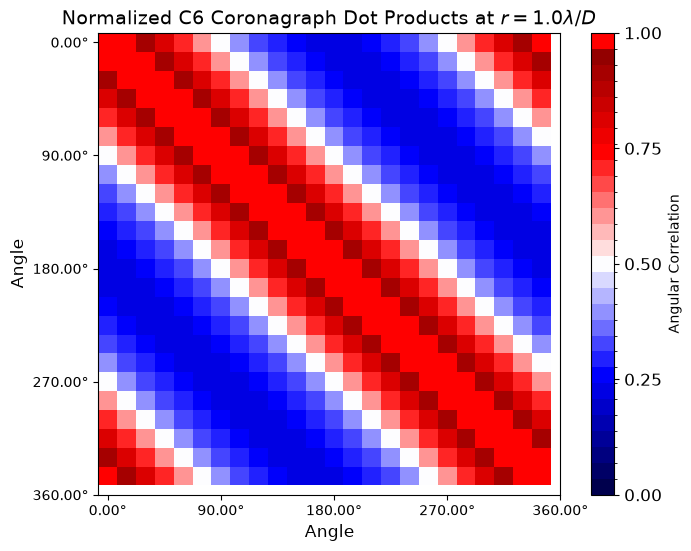

In [29]:
coron_thetas = np.arange(0,np.pi*2,np.pi/12)
coron_dot_matrix_1 = np.zeros((len(coron_thetas), len(coron_thetas)))
coron_dot_matrix_7 = np.zeros((len(coron_thetas), len(coron_thetas)))
for j, th1 in enumerate(coron_thetas):
    for k, th2 in enumerate(coron_thetas):
        coron_dot_matrix_1[j,k] = coron_dot_product(coron_psfs, coron_seps, 1, th1, th2, degree = False)
        coron_dot_matrix_7[j,k] = coron_dot_product(coron_psfs, coron_seps, 7, th1, th2, degree = False)


cmap = plt.cm.seismic
cmaplist = [cmap(i) for i in range(cmap.N)]
cmaplist[-1]='red' 
cmap = colors.LinearSegmentedColormap.from_list('Custom cmap', cmaplist, cmap.N)
norm = colors.BoundaryNorm(list(np.linspace(0, 1, 30)), cmap.N)
fig, ax = plt.subplots(figsize = (8,6))
plt.grid(False)
img = ax.imshow(coron_dot_matrix_1, cmap=cmap, norm=norm, animated=True)
cbar = plt.colorbar(img, label = "Angular Correlation", cmap = "seismic")
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])  
cbar.ax.tick_params(labelsize=12)
x_values = np.linspace(0, 2 * np.pi, 25)*180/np.pi
y_values = np.linspace(0, 2 * np.pi, 25)*180/np.pi
ax.set_xticks(np.arange(len(x_values))[::6])
ax.set_yticks(np.arange(len(y_values))[::6])
ax.set_xticklabels([f'{val:.2f}\u00b0' for val in x_values][::6], fontsize = 10)
ax.set_yticklabels([f'{val:.2f}\u00b0' for val in y_values][::6], fontsize = 10)
ax.set_xlabel("Angle", fontsize = 12)
ax.set_ylabel("Angle", fontsize = 12)
ax.set_title(r'Normalized C6 Coronagraph Dot Products at $r = 1.0 \lambda/D$', fontsize = 14)
plt.show()

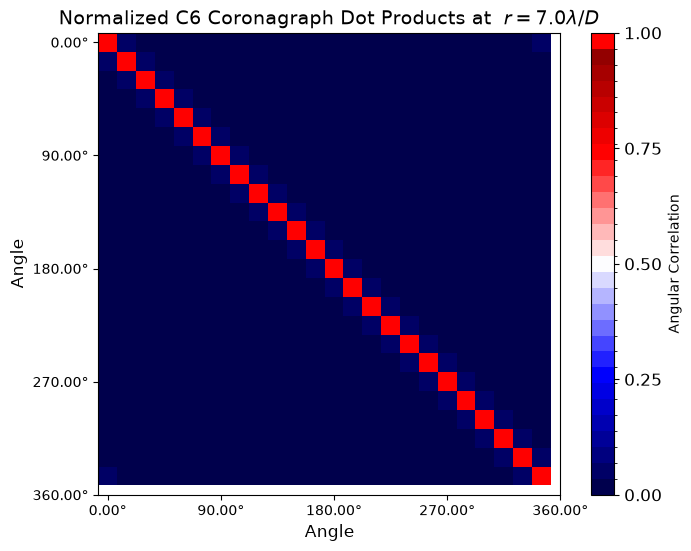

In [30]:
cmap = plt.cm.seismic
cmaplist = [cmap(i) for i in range(cmap.N)]
cmaplist[-1]='red' 
cmap = colors.LinearSegmentedColormap.from_list('Custom cmap', cmaplist, cmap.N)
norm = colors.BoundaryNorm(list(np.linspace(0, 1, 30)), cmap.N)
fig, ax = plt.subplots(figsize = (8,6))
plt.grid(False)
img = ax.imshow(coron_dot_matrix_7, cmap=cmap, norm=norm, animated=True)
cbar = plt.colorbar(img, label = "Angular Correlation", cmap = "seismic")
cbar.ax.tick_params(labelsize=12)  
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])  
x_values = np.linspace(0, 2 * np.pi, 25)*180/np.pi
y_values = np.linspace(0, 2 * np.pi, 25)*180/np.pi
ax.set_xticks(np.arange(len(x_values))[::6])
ax.set_yticks(np.arange(len(y_values))[::6])
ax.set_xticklabels([f'{val:.2f}\u00b0' for val in x_values][::6], fontsize = 10)
ax.set_yticklabels([f'{val:.2f}\u00b0' for val in y_values][::6], fontsize = 10)
ax.set_xlabel("Angle", fontsize = 12)
ax.set_ylabel("Angle", fontsize = 12)
ax.set_title(r'Normalized C6 Coronagraph Dot Products at  $r = 7.0 \lambda/D$', fontsize = 14)
plt.show()

In [36]:
coron_seps_fm = np.arange(0.5, 10.5, 0.5)
sep_inds = [np.where(coron_seps == x)[0][0] for x in coron_seps_fm] 
planet_data_pln_fm = np.zeros((5, 20, 6))
FR_pln = 0.01
for i in range (len(pln_seps_adi)):
        for j in range(len(pln_thetas_adi)):
                planet_data_pln_fm[i, j] = FR_pln*pln_psfs_adi[i,j]
pln_adi_fm_result = forward_model(planet_data_pln_fm, planet_data_pln_fm)

In [37]:
fm_data_combined_c6, fm_data_planet_c6, planet_windows_fm_c6, pre_fm_rms_c6 = fm_data_gen(coron_psfs_c6, coron_psfs_star_c6, rot_excl_angles, sep_inds, 1e-2)
fm_data_combined_c4, fm_data_planet_c4, planet_windows_fm_c4, pre_fm_rms_c4 = fm_data_gen(coron_psfs_c4, coron_psfs_star_c4, rot_excl_angles, sep_inds, 1e-2)
fm_data_combined_c2, fm_data_planet_c2, planet_windows_fm_c2, pre_fm_rms_c2 = fm_data_gen(coron_psfs_c2, coron_psfs_star_c2, rot_excl_angles, sep_inds, 1e-2)
fm_result_c6 = forward_model(fm_data_planet_c6, fm_data_planet_c6)
fm_result_c4 = forward_model(fm_data_planet_c4, fm_data_planet_c4)
fm_result_c2 = forward_model(fm_data_planet_c2, fm_data_planet_c2)
post_fm_I_rms_c6 = post_fm_I_rms(fm_result_c6, planet_windows_fm_c6)
post_fm_I_rms_c4 = post_fm_I_rms(fm_result_c4, planet_windows_fm_c4)
post_fm_I_rms_c2 = post_fm_I_rms(fm_result_c2, planet_windows_fm_c2)
rms_ratio_c6 = pre_post_ratio(post_fm_I_rms_c6, pre_fm_rms_c6)
rms_ratio_c4 = pre_post_ratio(post_fm_I_rms_c4, pre_fm_rms_c4)
rms_ratio_c2 = pre_post_ratio(post_fm_I_rms_c2, pre_fm_rms_c2)
pre_fm_pln_rms = np.zeros((5,20))
post_fm_pln_rms = np.zeros((5,20))
for i in range(0, planet_data_pln_fm.shape[0]):
    for j in range(0, planet_data_pln_fm.shape[1]):
        pre_fm_pln_rms[i,j] = np.sqrt(np.mean(planet_data_pln_fm[i,j,1:5]**2))
        post_fm_pln_rms[i,j] = np.sqrt(np.mean(pln_adi_fm_result[i,j,1:5]**2))
adi_rms_ps_fm_pln_inv = np.mean(post_fm_pln_rms/pre_fm_pln_rms, axis = 1)


plt.scatter(coron_seps_fm, rms_ratio_c6, label = "Coronograph C6", c= "b")
plt.scatter(coron_seps_fm, rms_ratio_c4, label = "Coronograph C4", c= "y")
plt.scatter(coron_seps_fm, rms_ratio_c2, label = "Coronograph C2", c= "r")
plt.scatter(pln_seps_adi, adi_rms_ps_fm_pln_inv, label = "PLN", c= "g", marker = "x", s = 50)
plt.legend(loc = "lower right")
plt.xlabel(r"Separation ($\lambda$/d)", fontsize = 10)
plt.ylabel("RMS Planet Signal Intensity Ratio", fontsize = 10)
plt.title("Self Subtraction from Angular Differential Analysis of Planet Signal", fontsize = 12)
plt.show()